<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Import" data-toc-modified-id="Import-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Import</a></span></li><li><span><a href="#Data-from-Ana" data-toc-modified-id="Data-from-Ana-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Data from Ana</a></span></li><li><span><a href="#Visualisation" data-toc-modified-id="Visualisation-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Visualisation</a></span></li><li><span><a href="#Run-simulations" data-toc-modified-id="Run-simulations-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Run simulations</a></span></li><li><span><a href="#Run-gradient" data-toc-modified-id="Run-gradient-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Run gradient</a></span></li><li><span><a href="#Run-opti-diagram" data-toc-modified-id="Run-opti-diagram-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Run opti diagram</a></span></li></ul></div>

## Import 

In [1]:
# plotting stuff
import matplotlib as mpl
mpl.use('TkAgg')
%matplotlib inline

COLOR = 'white'
COLOR2 = 'black'

mpl.rcParams['text.color'] = COLOR
mpl.rcParams['axes.labelcolor'] = COLOR
mpl.rcParams['xtick.color'] = COLOR
mpl.rcParams['ytick.color'] = COLOR
mpl.rcParams['axes.edgecolor'] = COLOR

mpl.rcParams["figure.facecolor"] = COLOR2
mpl.rcParams["axes.facecolor"] = COLOR2
mpl.rcParams["savefig.facecolor"] = COLOR2

import matplotlib.pyplot as plt
from cycler import cycler


# numbers handling
import numpy as np
from numpy import pi
import pandas as pd

# signal processing 
from scipy.signal import savgol_filter, correlate, correlation_lags
from scipy.interpolate import interp1d


# to hide known warnings
import warnings
warnings.filterwarnings("ignore")

# General system functions
import os
import shutil
import sys

import time

# my functions
sys.path.append('../PythonFuncs/')
import VallapFunc_DP as vf
import DropGeometryClasses as dgc
import DropGeometryFuncs as dgf
import ImpactSimulationFuncs as isf


## Data from Ana

In [2]:

# data = pd.read_csv(r'd:\Users\laplaud\Desktop\PostDoc\Data\SplashCups\DataAna\all_angles.csv')
# data['OffC_CD'] = data['OffCentering']/data['TargetDiam']*2
# data['DD_CD'] = data['DropDiam']/data['TargetDiam']
# data.loc[data['SplashType']=='Bell','color'] = 'r'
# data.loc[data['SplashType']=='Crown','color'] = 'r'
# data.loc[data['SplashType']=='Jet','color'] = 'b'
# data.loc[data['SplashType']=='Transition','color'] = 'g'

# data.plot.scatter('OffC_CD','DD_CD',c = 'color', label = None)
# plt.plot(-1,-1,'or',label = 'Splash')
# plt.plot(-1,-1,'og',label = 'Transition')
# plt.plot(-1,-1,'ob',label = 'Jet')
# plt.xlim(0,1.8)
# plt.ylim(0,1.8)
# plt.xlabel('Offcentering/ConeSize')
# plt.ylabel('DropSize/ConeSize')
# plt.plot([0,2],[0,2],'--k',label = 'Offcentering = DropSize')
# plt.plot([1,1],[0,1],'-.k',label = 'Offcentering = ConeSize')
# plt.legend(fontsize = 'x-small', loc=4)
# plt.gca().set_aspect('equal')

## Visualisation

0.1


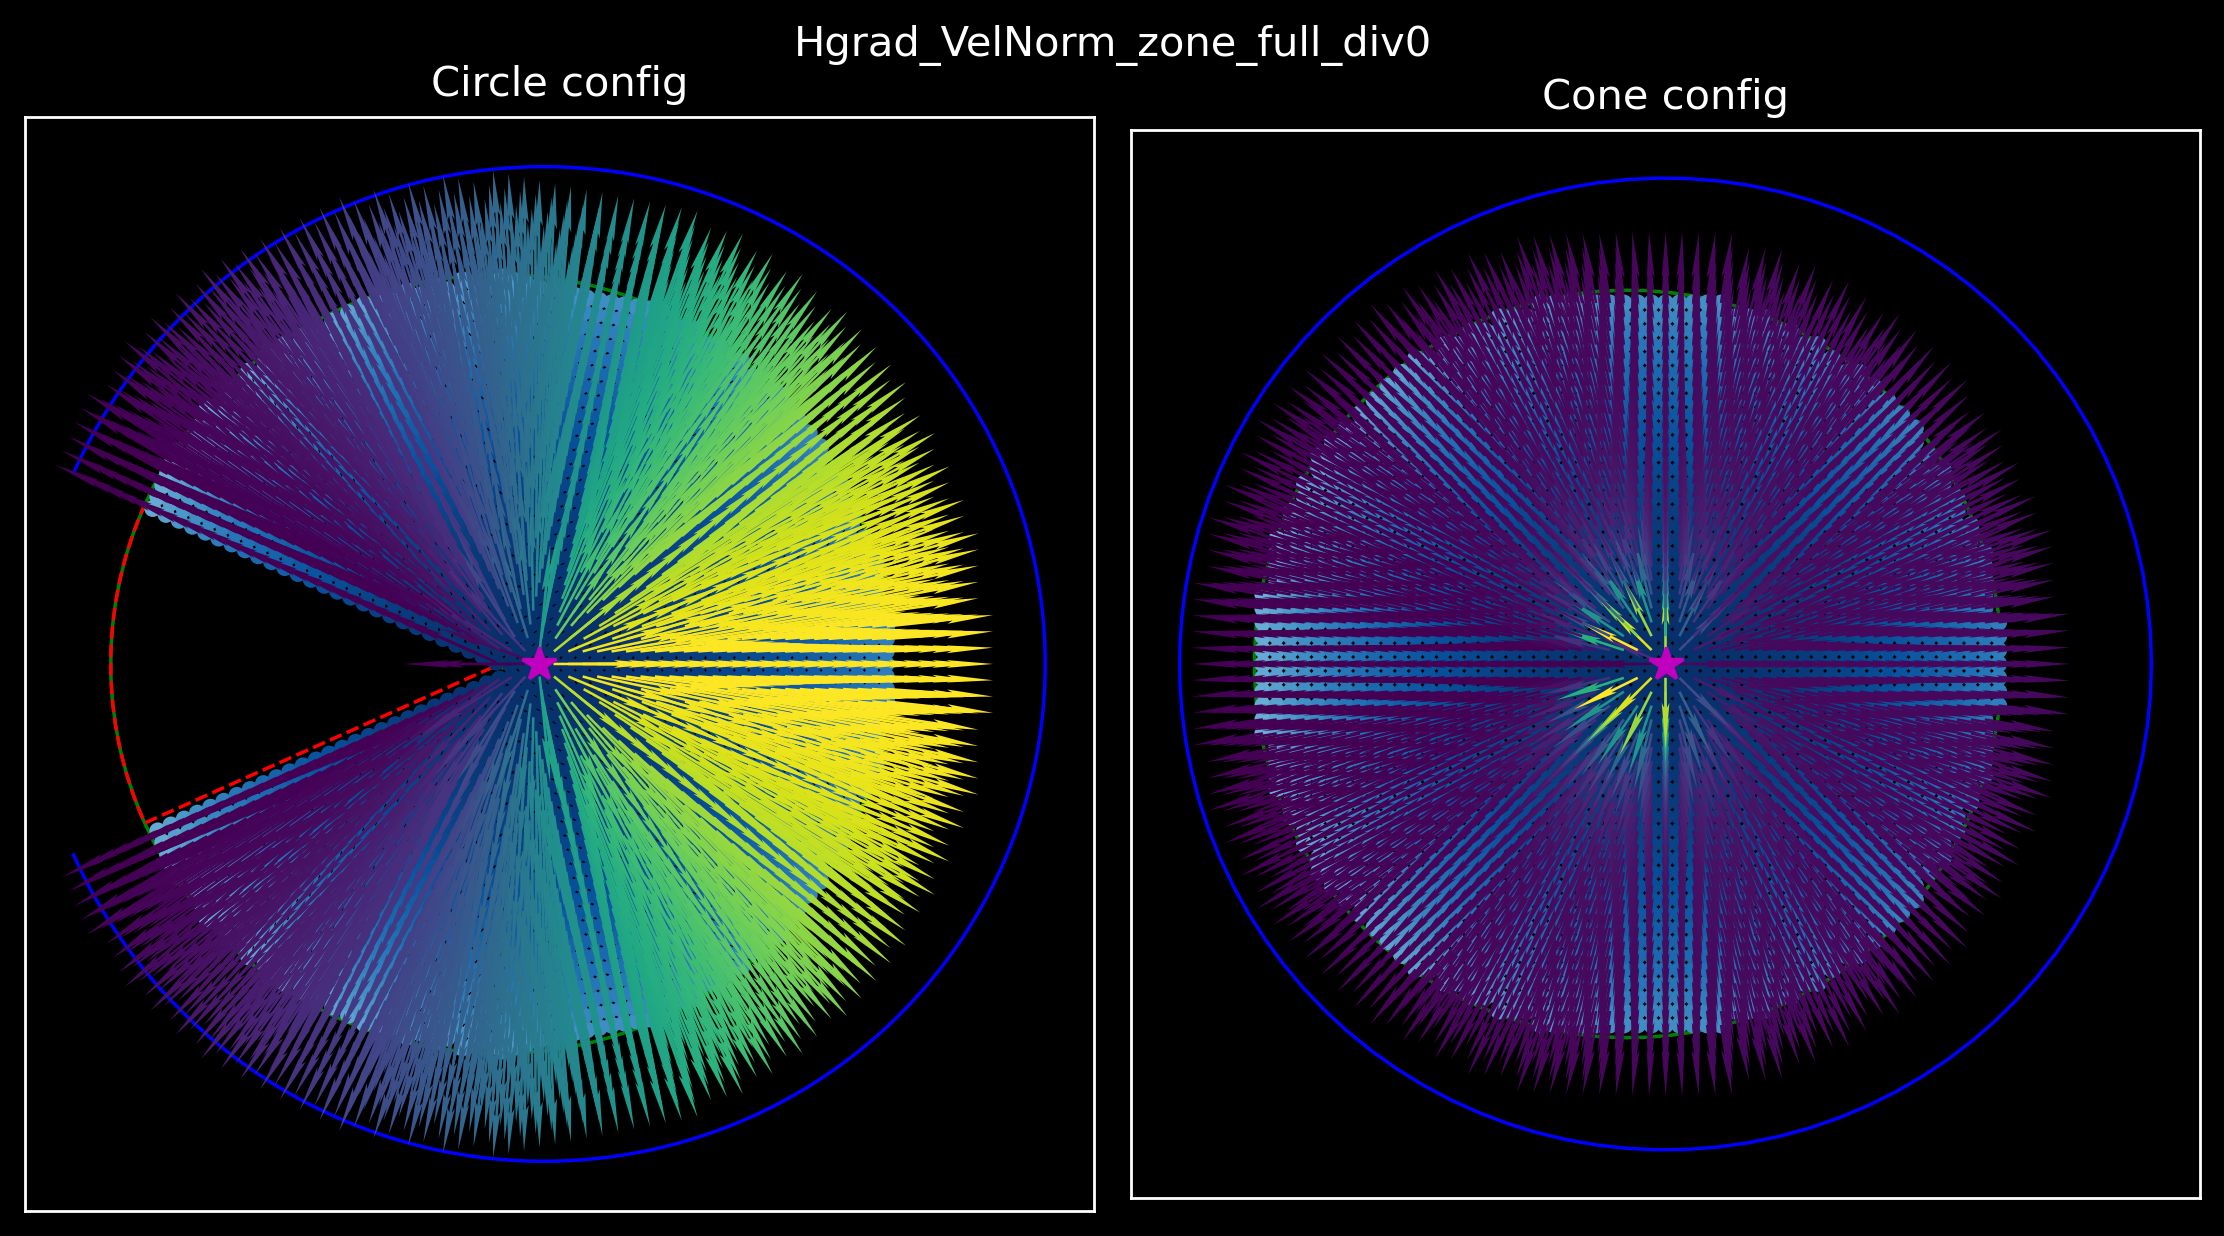

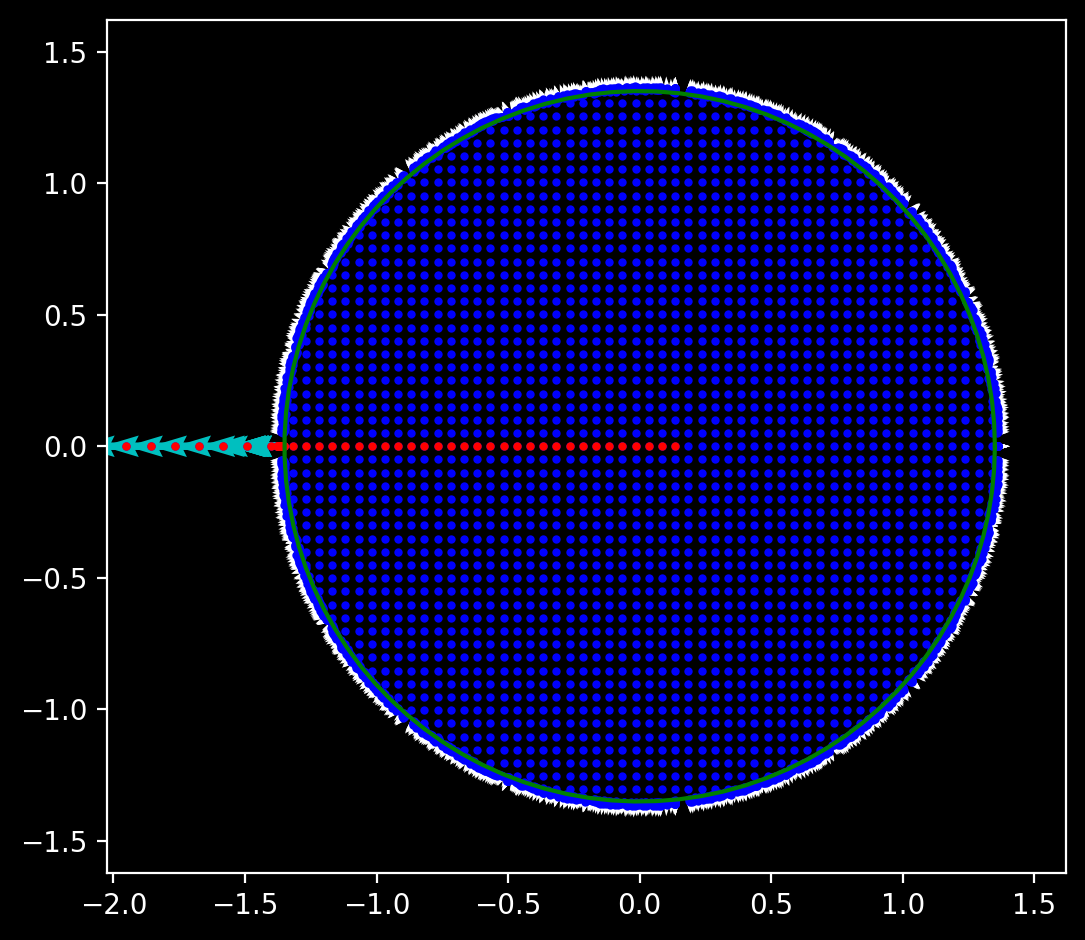

0.5


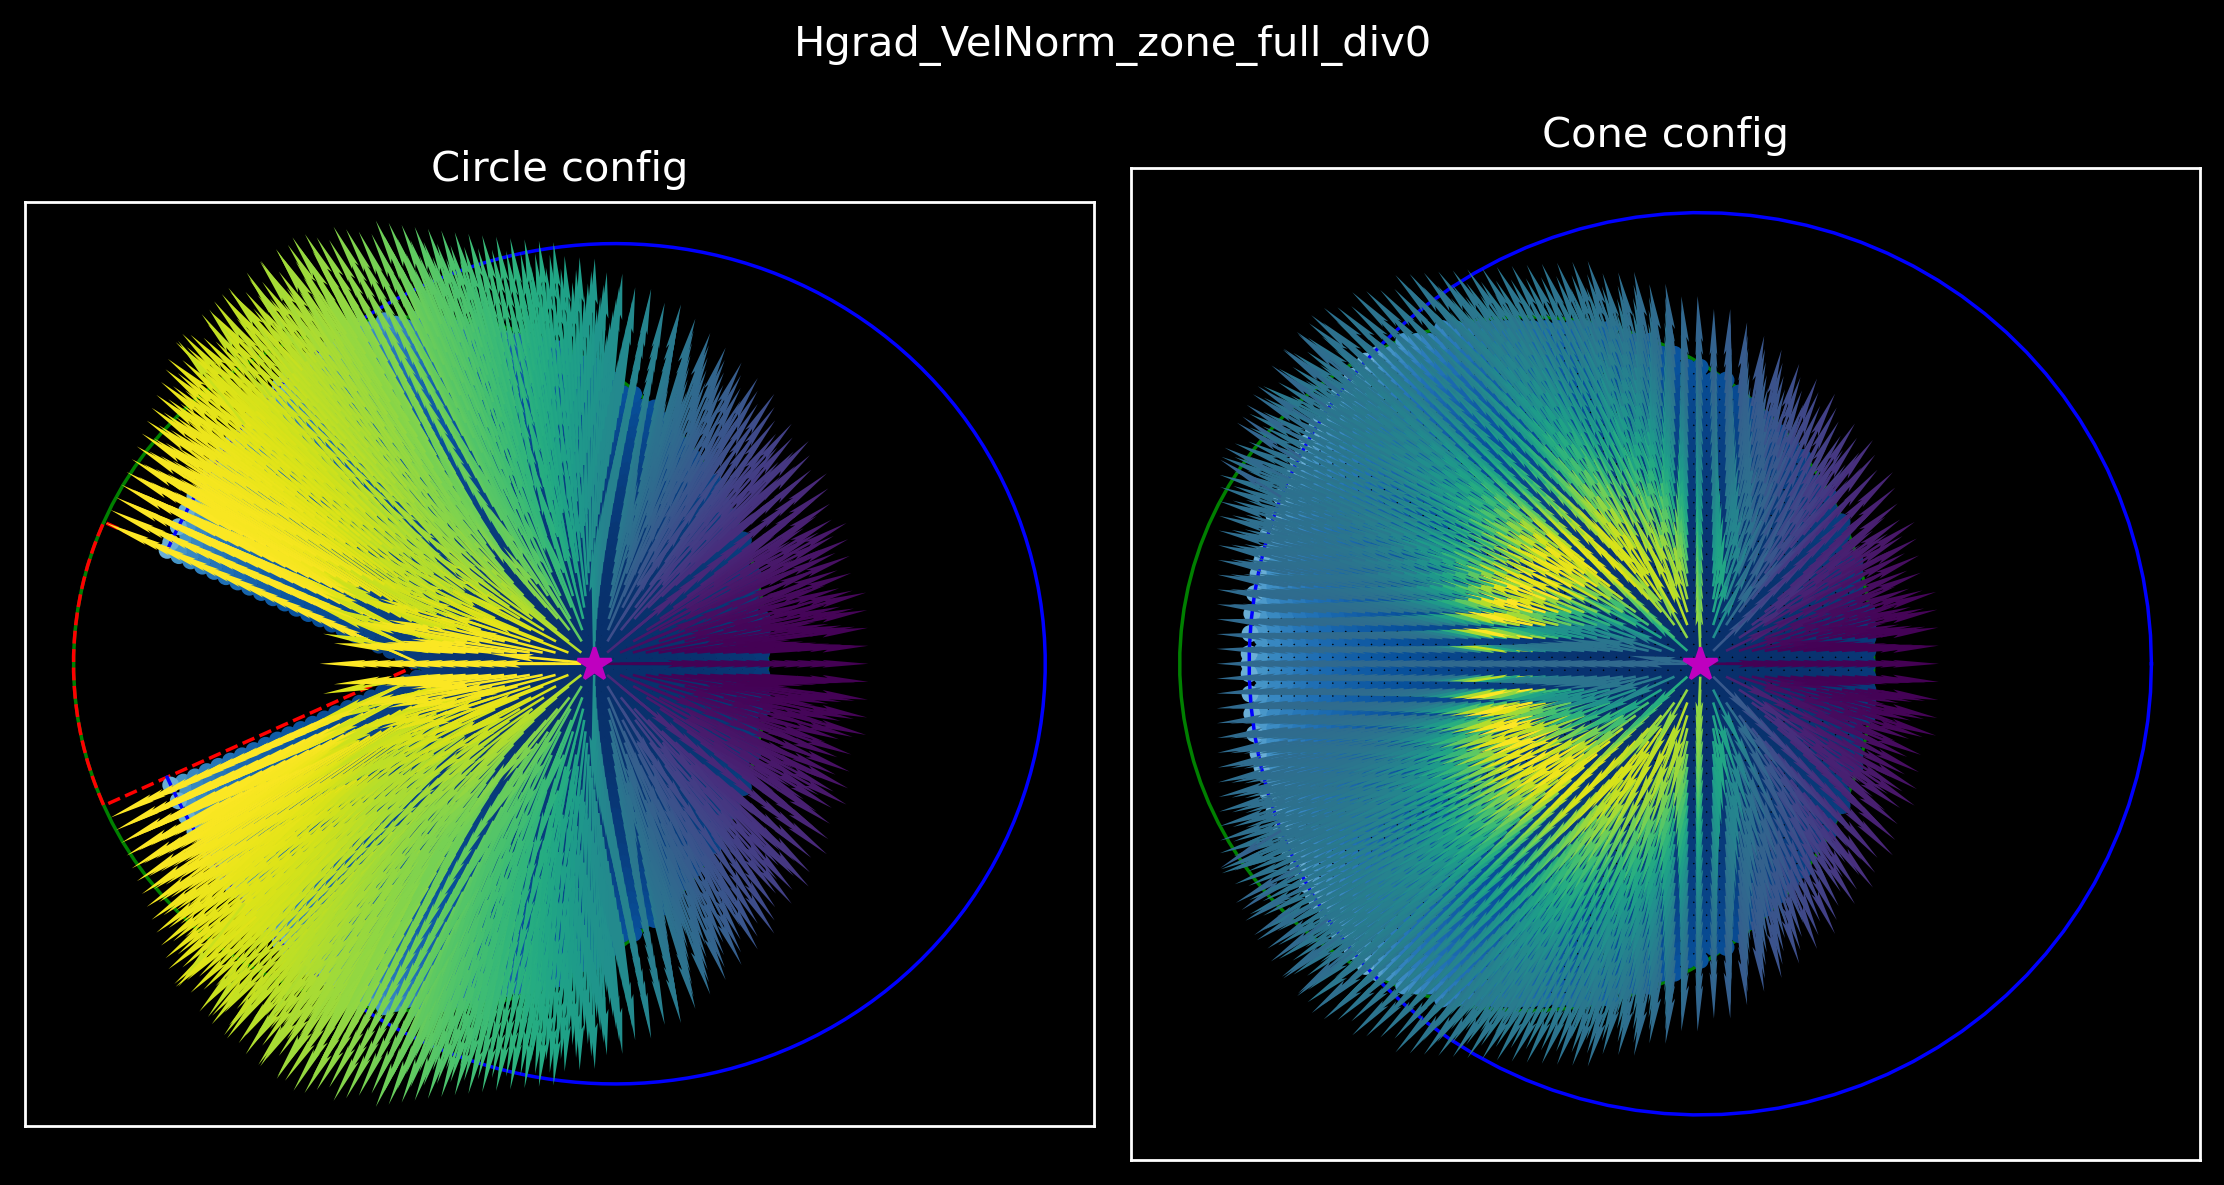

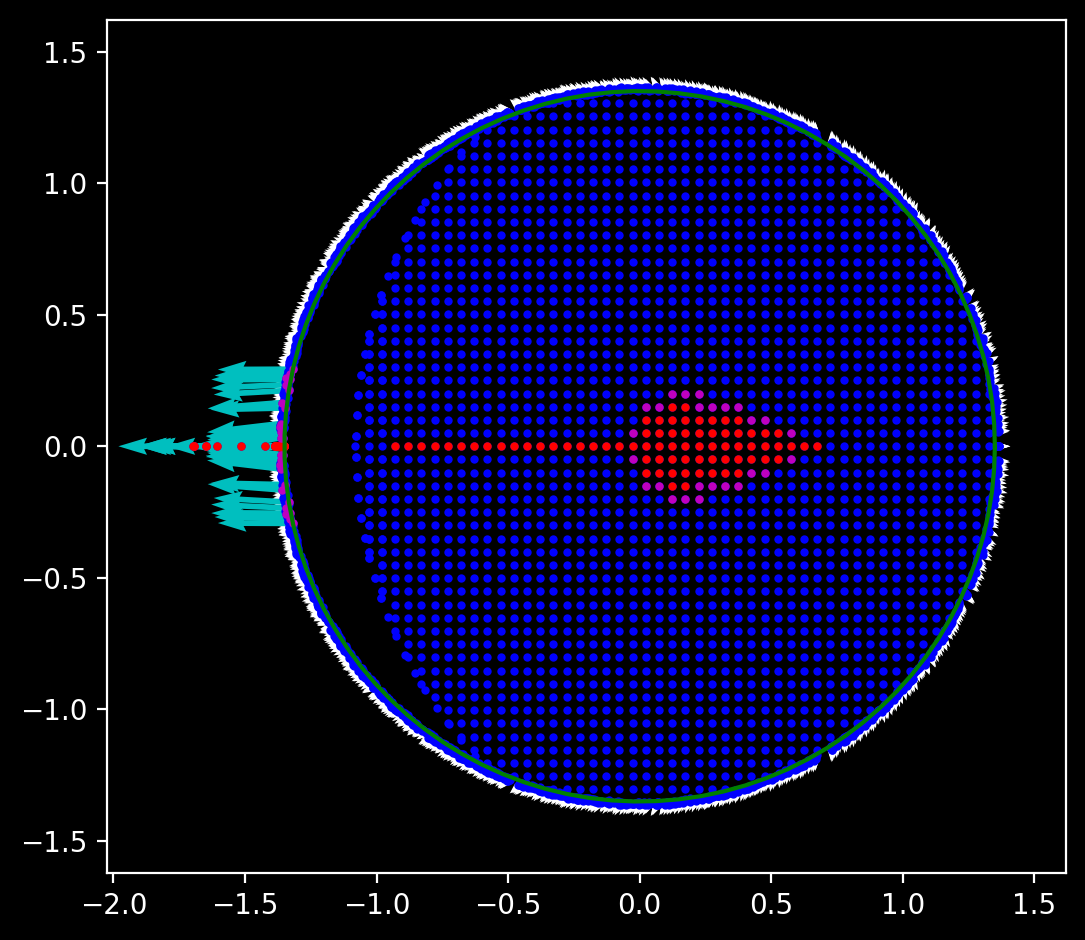

0.9


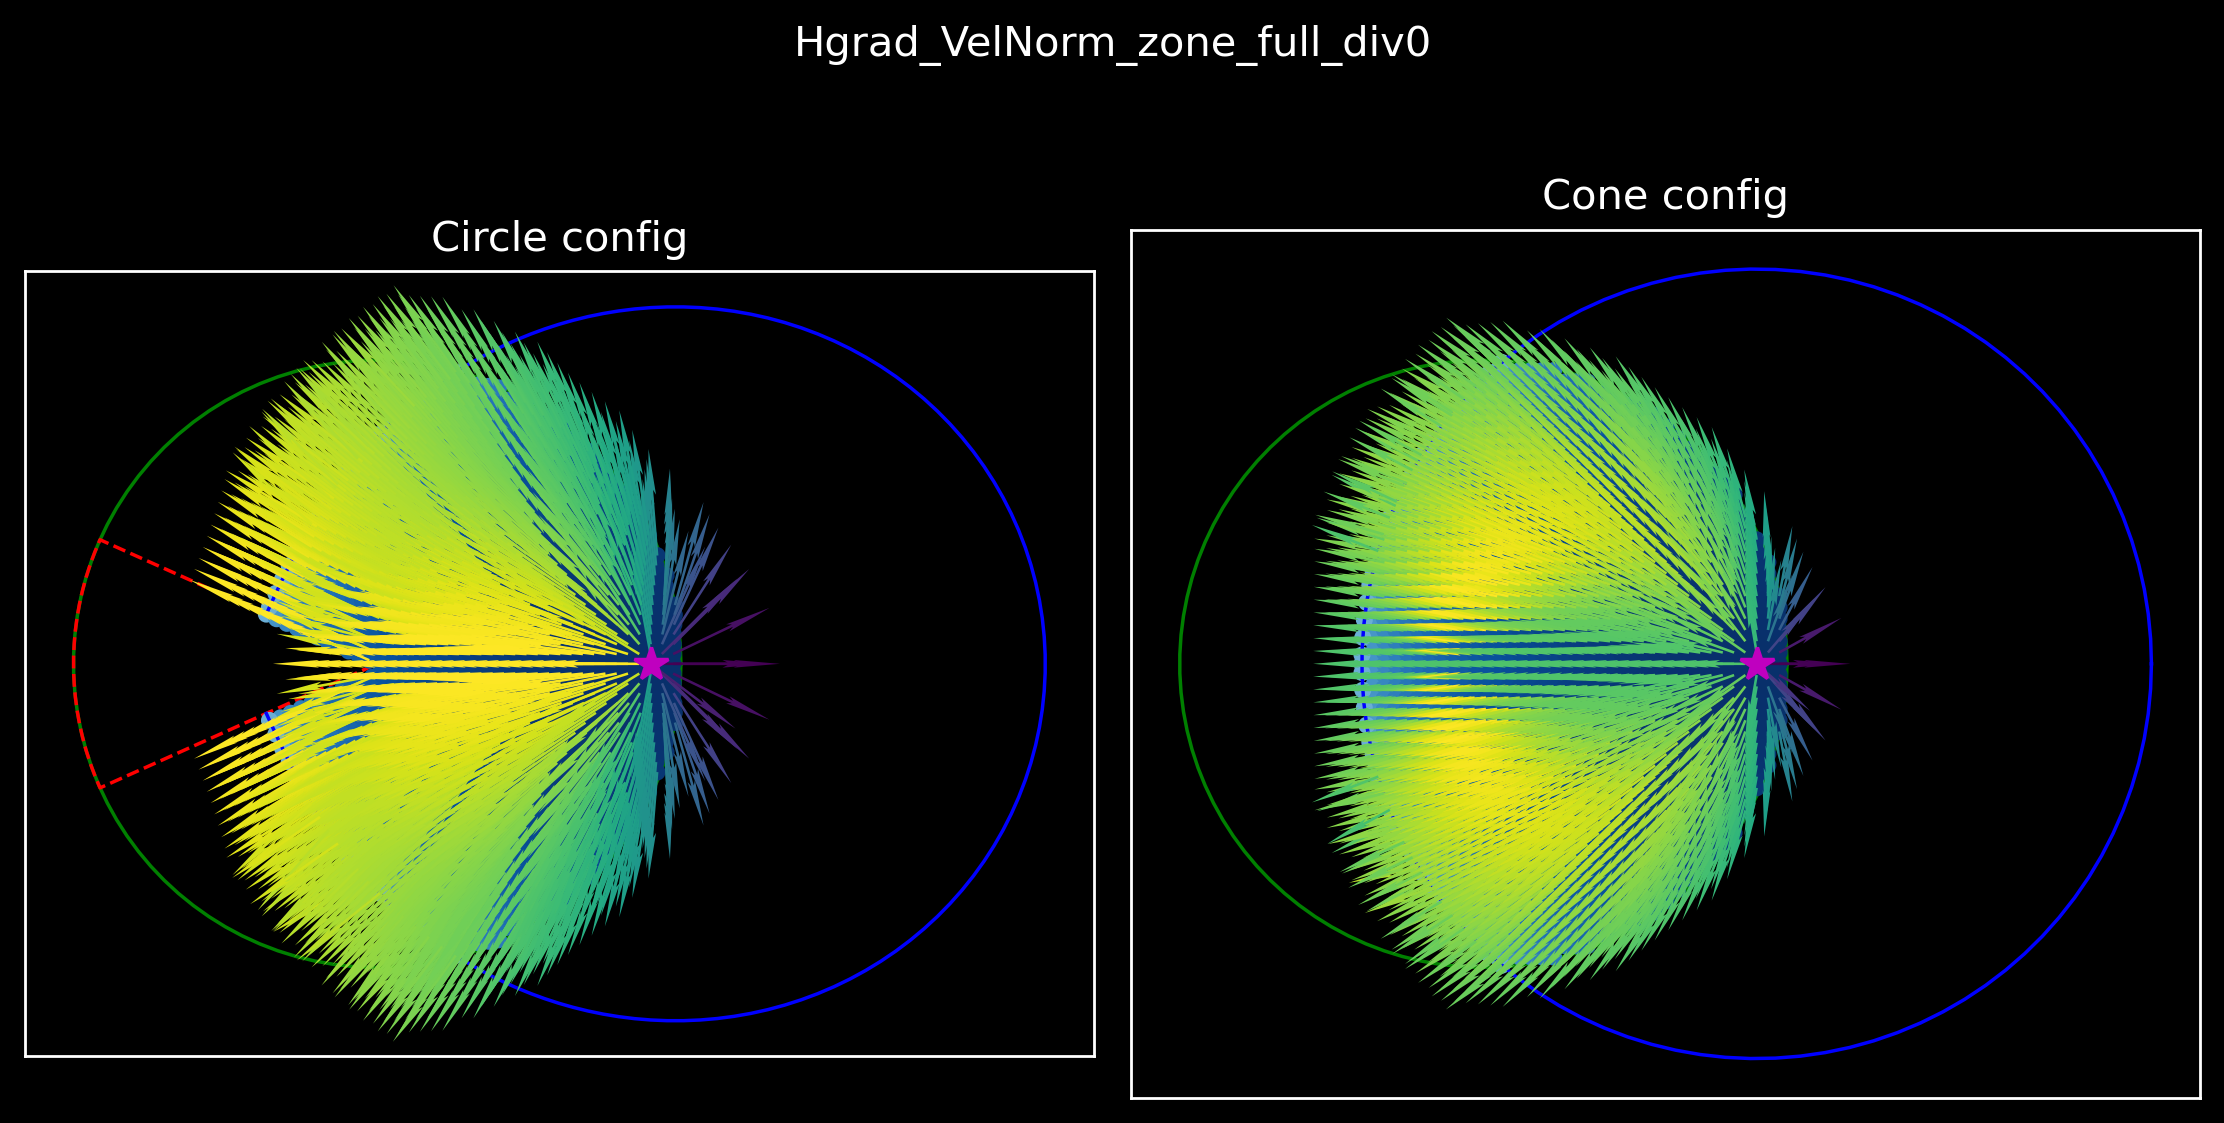

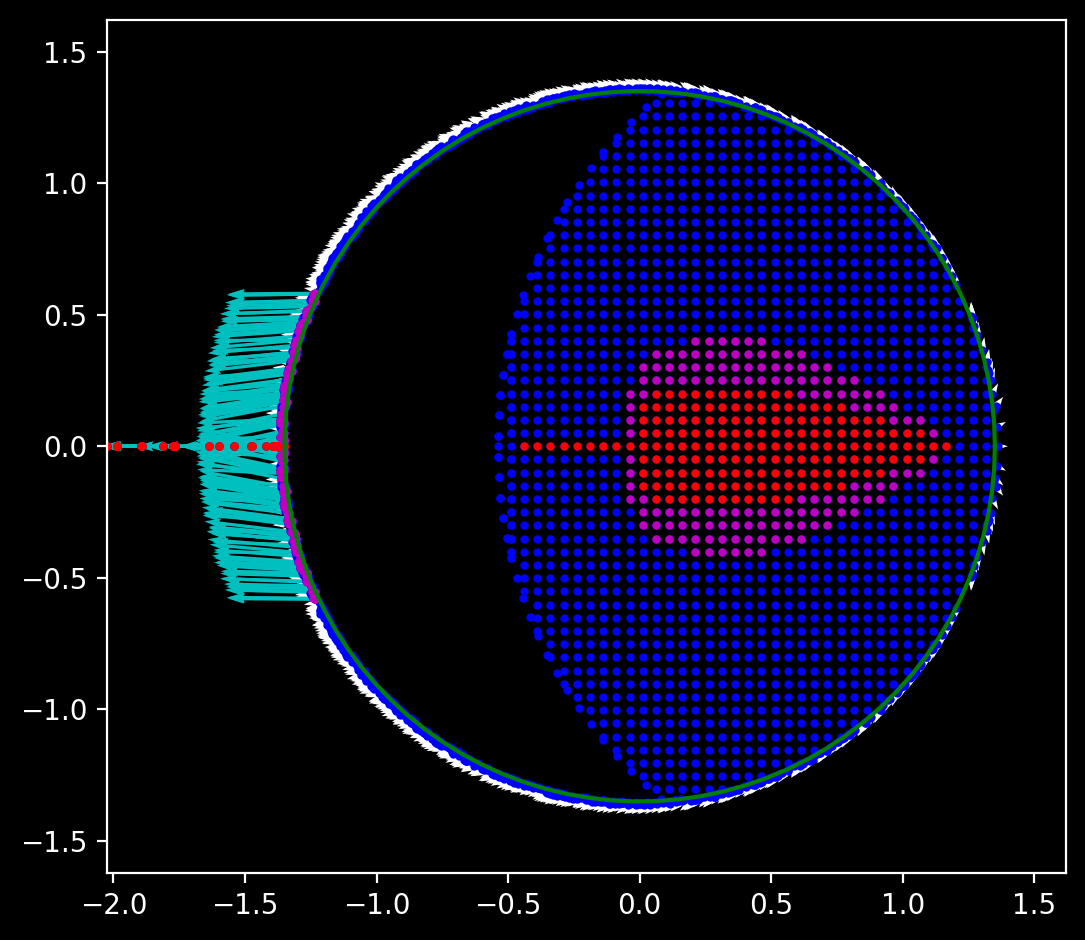

1.3


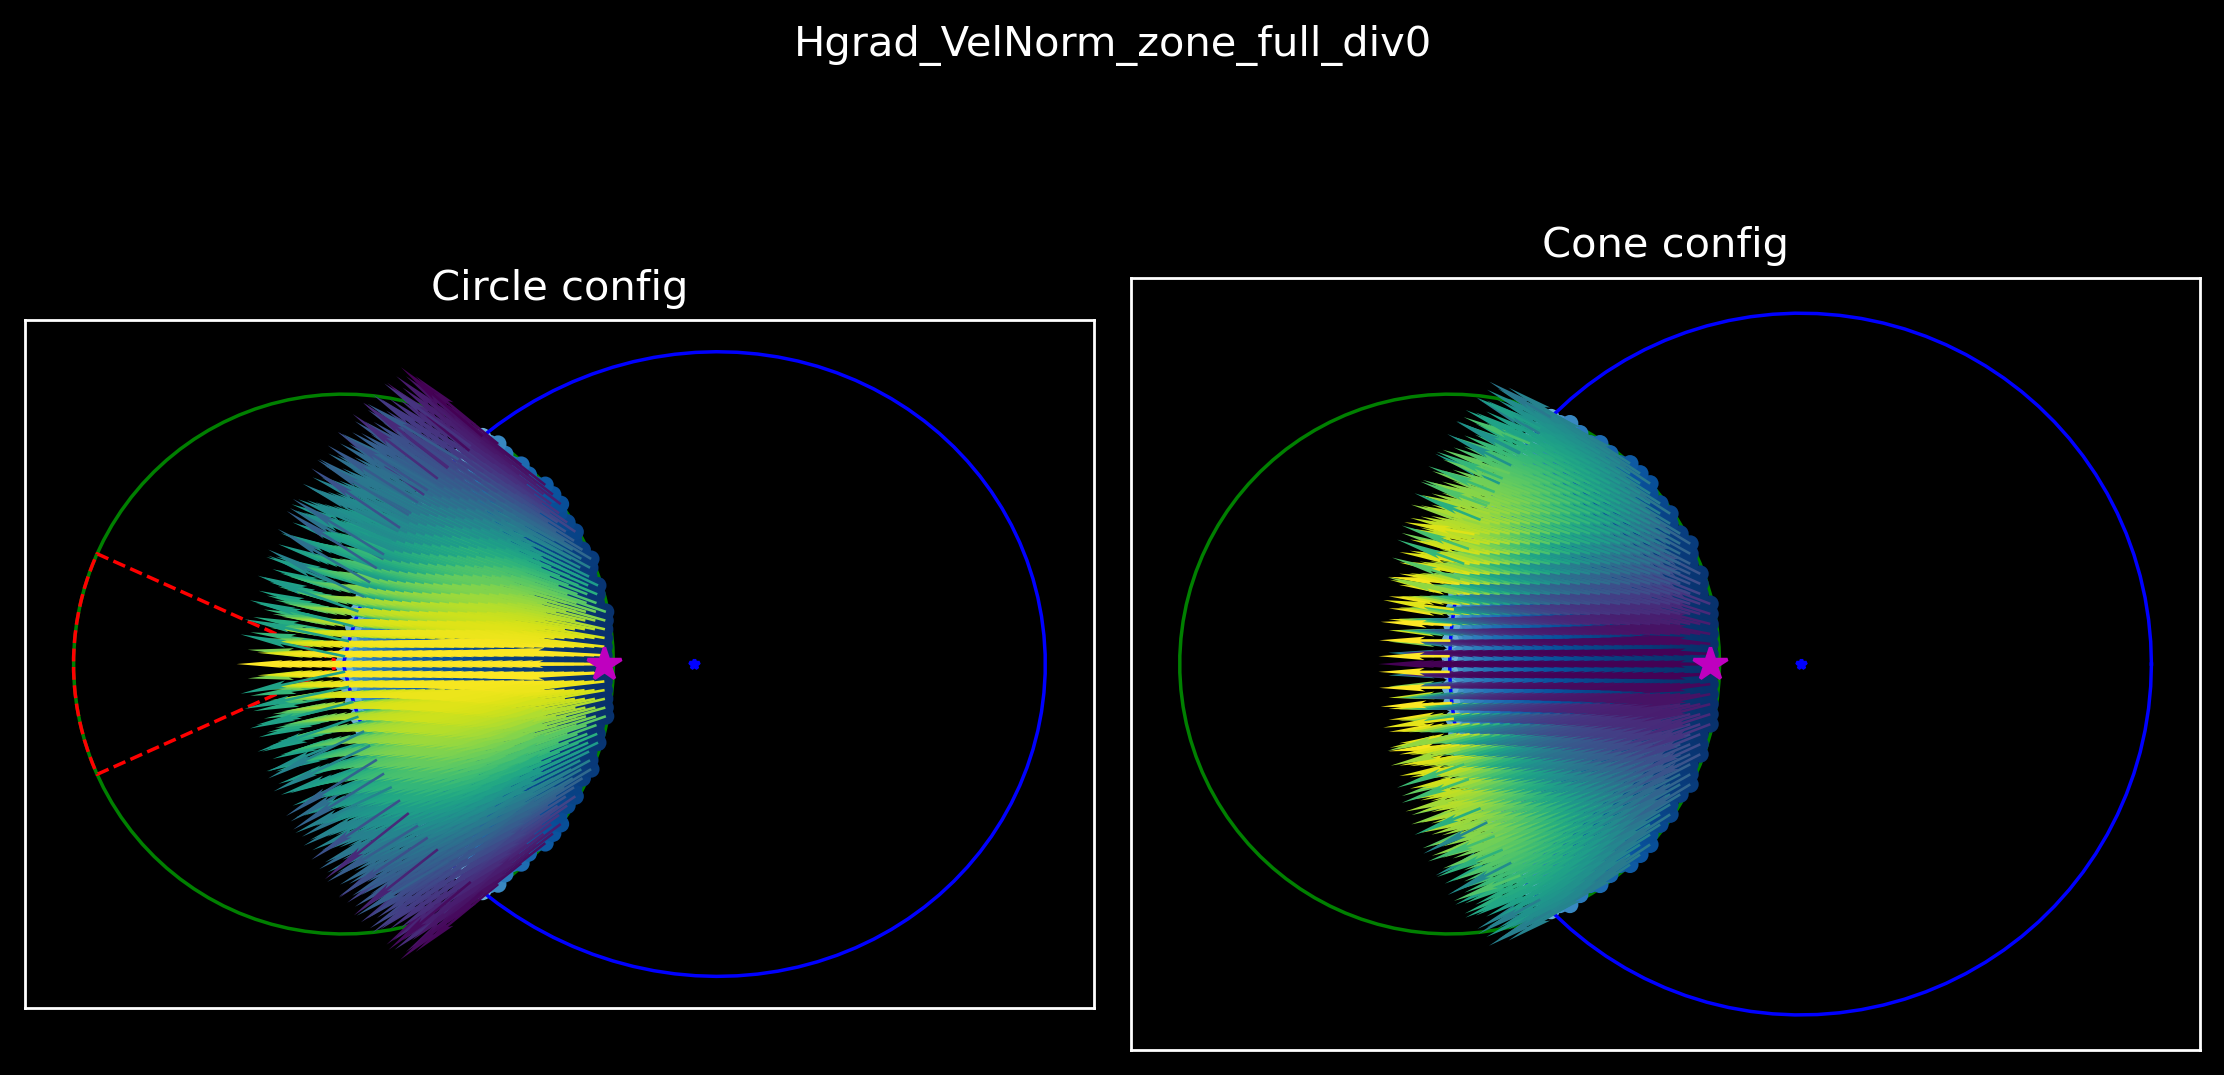

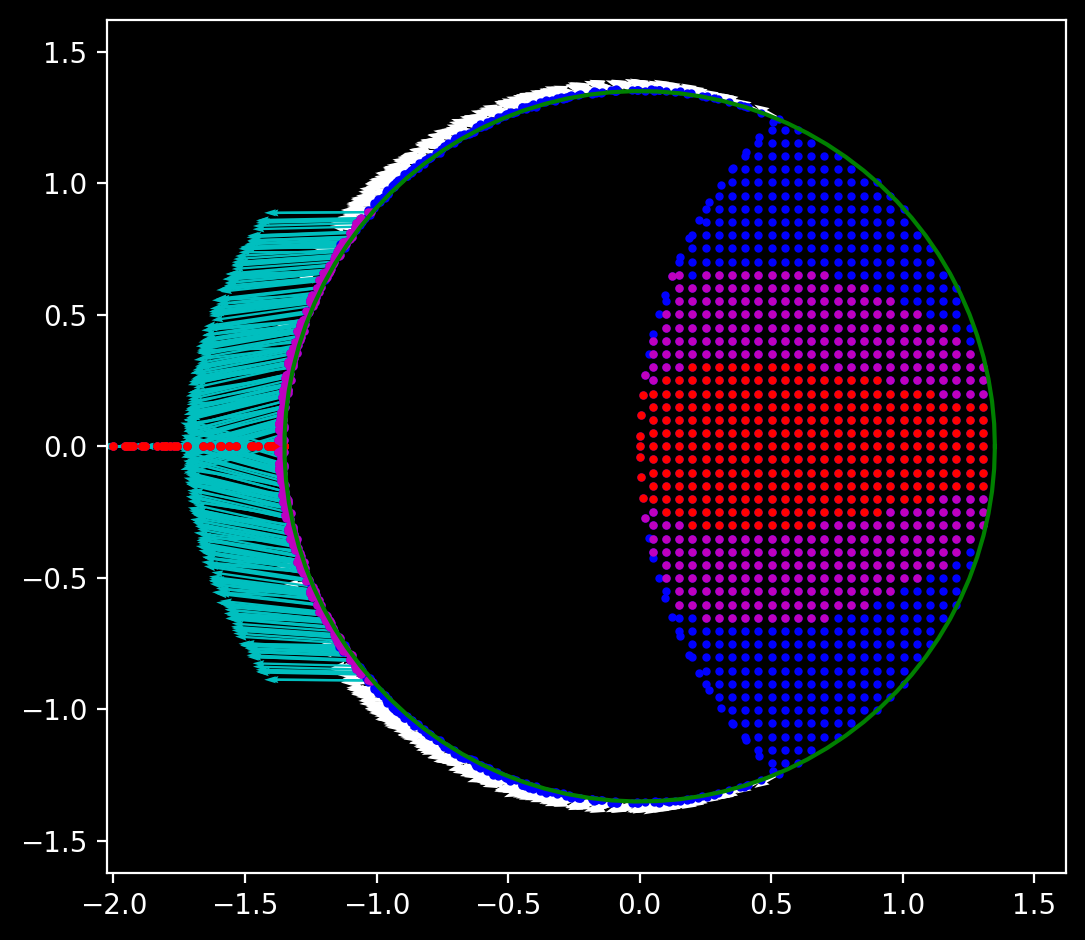

1.6


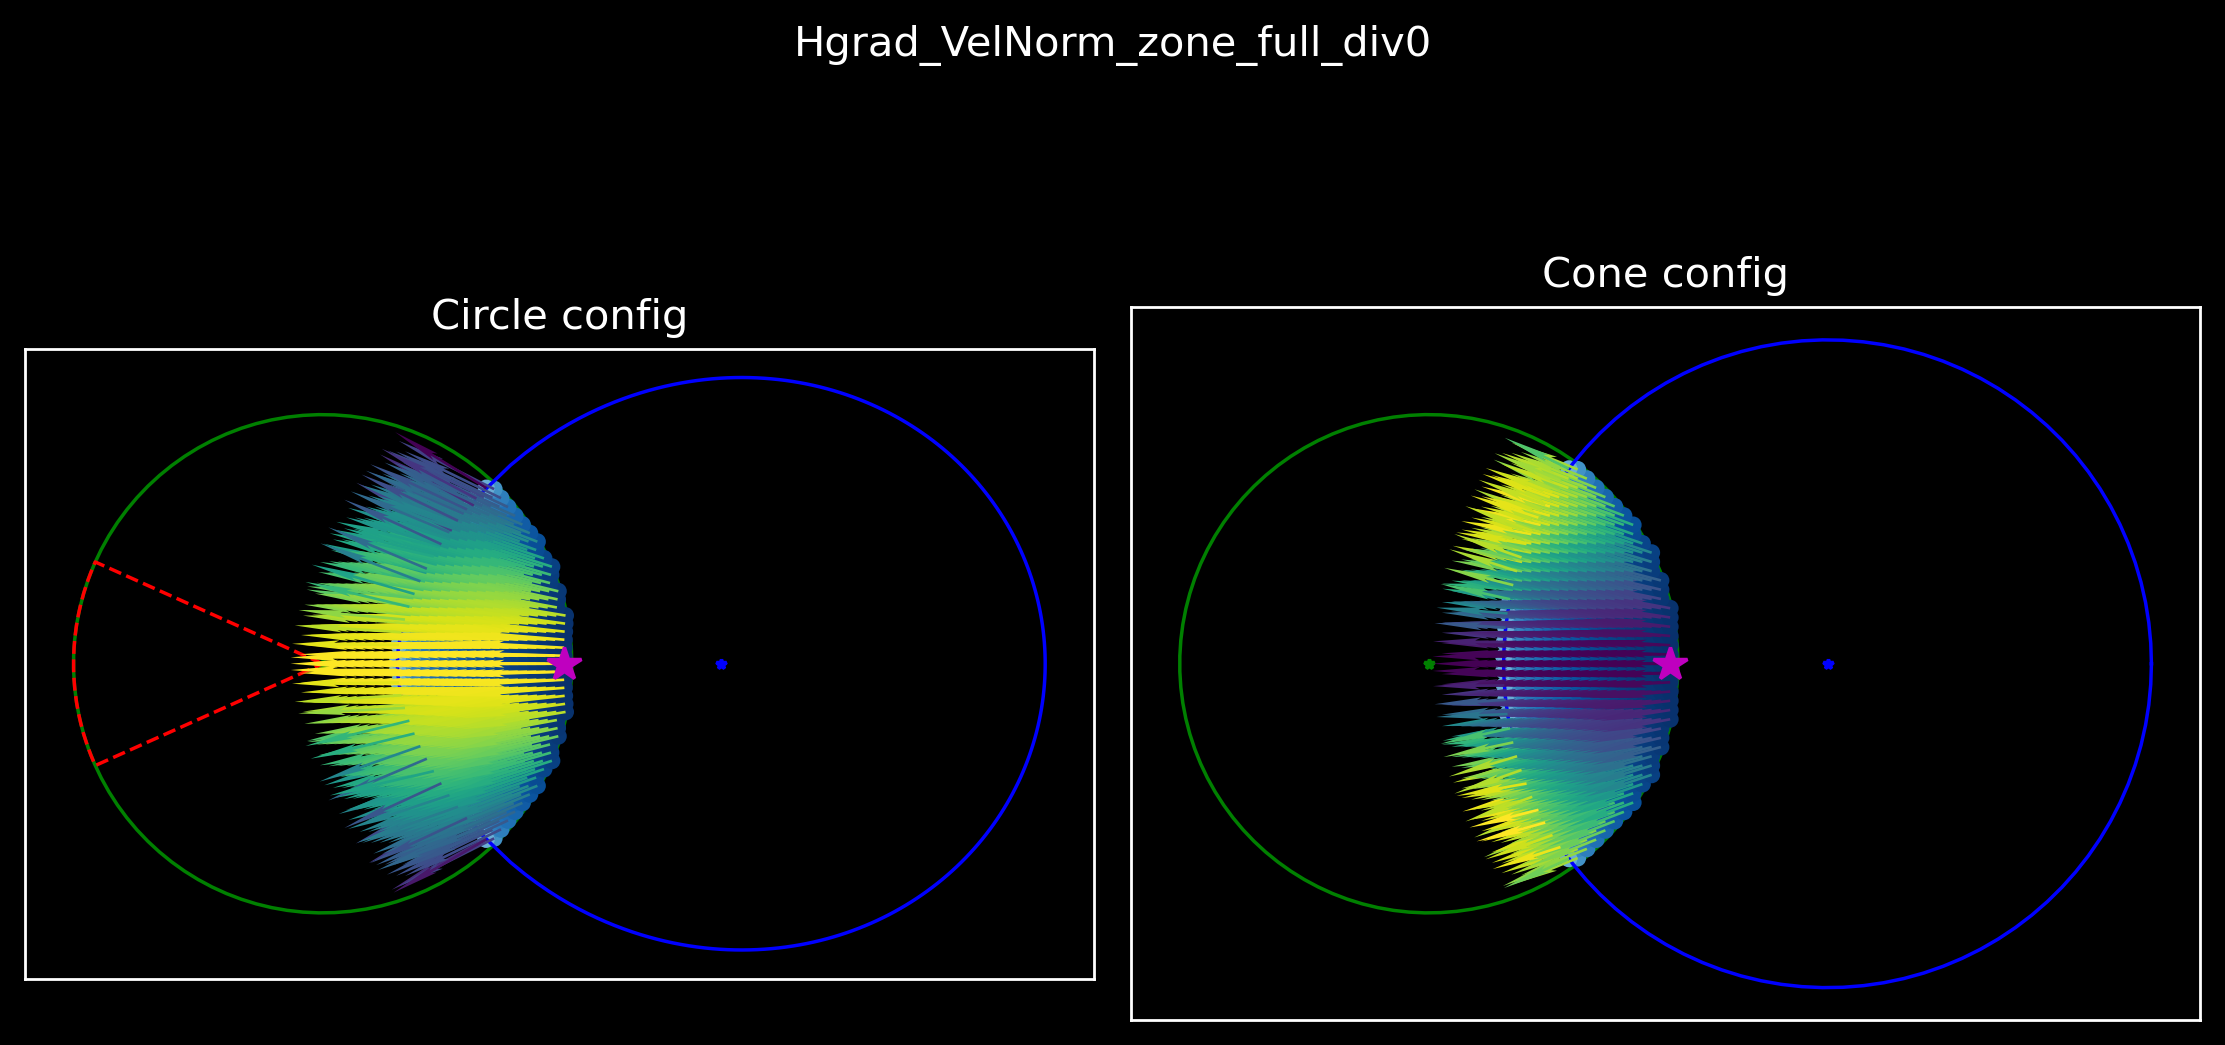

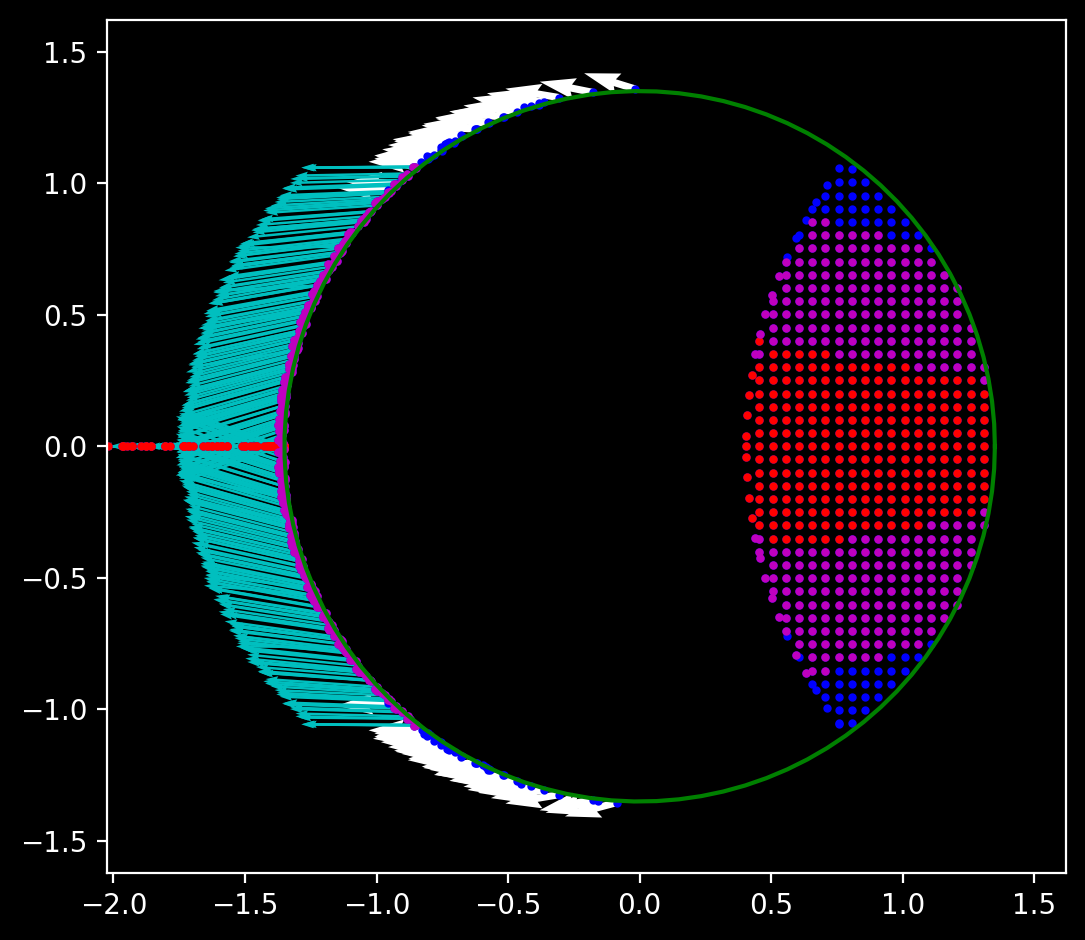

In [3]:

npts =71
ConeDiam = 2.7
DropDiam = ConeDiam*1.3

Rocs = np.round(np.linspace(0.051,1.65,5)*10)/10
# Roc = 0.9
for Roc in Rocs:
    
    print(Roc)
    D = dgc.Drop(DropDiam/2,Roc*ConeDiam/2,npts,5)
    C = dgc.Cone(ConeDiam/2,np.pi/3)

    start_time = time.time()

    oriType = 'Hgrad'
    velIni = 'VelNorm'
    meshType = 'zone'

    title = oriType + '_' + velIni + '_' + meshType

    I = C.impact(D,oriType,velIni,meshType)
    # I2 = C.impact(D,'Drop','Radial','zone')

#     I.compute_ShapeFactor(np.linspace(0,2,50),0.5)
    I.plot_splash_init('full_div0',nolabels=True,title=title)
#     I.compute_JetFrac()

# I.plot_splash_init(veltype='norm',nolabels=True,title=title)

# print("\nTotal time : %.04f milliseconds" % ((time.time() - start_time)*1000))

# I.plot_splash_traj(np.linspace(0,1,20),'full_div0',nolabels=True,title=title)
# # I2.plot_splash_traj(np.linspace(0,1,20),'full_div0',nolabels=True)
    



In [4]:

# npts = 151
# ConeDiam = 4.3
# Rdds = [0.7,1.4]

# # Roc = 0.05

# Angles = [np.pi/3,np.pi/4,np.pi/6]
# # Angles = [np.pi/4]

# oriType = 'Hgrad'
# velIni = 'Radial'
# meshType = 'zone'

# Time = 4# ms

# Rocs = [0.05, 0.7, 1.2]
# Rocs = [0.8,1.3]


# for Roc in Rocs:

#     for Angle in Angles:
        
#         for Rdd in Rdds :
        
        
#             title3D = 'Roc' + str(Roc) + '_Angle' + str(np.round(Angle/np.pi*1800)/10) + '_Rdd' + str(Rdd)
#             print(title3D)
#             DropDiam = ConeDiam*Rdd 

#             D = dgc.Drop(DropDiam/2,Roc*ConeDiam/2,npts,5)
#             C = dgc.Cone(ConeDiam/2,Angle)

#             title = (oriType + '_' + velIni + '_' + meshType + '_Ang' +
#                     str(np.round(Angle/np.pi*1800)/10) +  '_ROC' + str(Roc) + '_RDD' + str(Rdd) +
#                     '_UpTo' + str(Time) + 'ms' + '_npts' + str(npts))

#             I = C.impact(D,oriType,velIni,meshType)

#             # I.plot_splash_init(veltype='full_div0',nolabels=True,title=title)
#             # I.plot_splash_init(veltype='norm',nolabels=True,title=title)
            
# #             I.plot_3Dview(title3D)
# #             I.plot_3Dproj(title3D,15)
            
#             # I.plot_splash_traj(np.linspace(0,Time,20),'full_div0',nolabels=False,title=title)
#     #         I.plot_splash_movie(np.linspace(0,Time,200),title,[-10,10],[-10,10],nolabels=True)



## Run simulations

In [5]:

# oriType = 'Hgrad' # ,'Hmax','Central','CentralHeight','Drop'

# velType = 'full_div0'

# velIni = 'Radial' # 'VelNorm',

# meshType = 'zone'

# npts = 31 # XY resolution for the diagram

# OffCmax = 3 # [mm]

# marchantias = ['radius','polymorpha'] #,'polymorpha','globosa'

# for marchantia in marchantias:
#     if marchantia == 'polymorpha':
#         ConeSize = 7.3 # [mm²] polymorpha :7.3 globosa : 12.1
#         RelOffCmax = OffCmax/np.sqrt(ConeSize/np.pi)
#         ConeSizeType = 'surface'
#     elif marchantia == 'globosa':
#         ConeSize = 12.1 # [mm²] polymorpha :7.3 globosa : 12.1
#         RelOffCmax = OffCmax/np.sqrt(ConeSize/np.pi)
#         ConeSizeType = 'surface'
#     elif marchantia == 'radius':
#         ConeSize = 3 # [mm] 
#         RelOffCmax = OffCmax
#         ConeSizeType = 'radius'
#     # 

#     # parameter space
#     RelDropDiams = np.linspace(0.125,RelOffCmax-1,npts)

#     RelOffCents = np.linspace(0.125,RelOffCmax,npts)

#     Angles = np.linspace(0.5,89.5,npts)/360*2*np.pi

#     label = 'NewVel_' + velIni + '_' + oriType + '_' + velType + '_' + meshType + '_' + marchantia

#     print('\n\nRunning for : ' + label + '\n')

#     start_time = time.time()

#     isf.PhaseDiagrams(RelOffCents,ConeSize,ConeSizeType,Angles,RelDropDiams,oriType,velType,velIni,meshType,label)


## Run gradient

In [6]:
# # Path
# path = r'd:\Users\laplaud\Desktop\PostDoc\Code\DropProject_WithAna\Figures'
# # Parameters


# npts = 41 # XY resolution for the diagram

# ConeDiam = 2.7 # Diameter in [mm]
# # 
# OffCmax = 3 # 

# DiagDim = 2

# # plots param
# data = 'DispertionDist'
# label = 'Dispertion distance [mm]'




# marktype = 's'

# colormap = 'plasma' # 'PuOr' 'cividis' 'plasma' 'jet' 'rainbow'

# pointSize =17000/npts**2

# # parameter space
# RelDropDiams = np.linspace(0.25,OffCmax-1,npts)

# RelOffCents = np.linspace(0.25,OffCmax,npts)

# Angles = np.linspace(20,70,npts)/360*2*np.pi


# DD = RelDropDiams*ConeDiam

# OC = RelOffCents*ConeDiam/2

# meshA,meshDD,meshOC = np.meshgrid(Angles,DD,OC)    

# marchantia= 'radius'

# folder = 'Radial_Hgrad_full_div0_zone_' + marchantia + '_'+  str(npts) + 'npts'
# title = 'Hgrad_Radius'

# print('Working on ' + folder)

# loadpath = path + '\\' + folder


# Data = np.load(loadpath + '\Data_' + data + '_' + str(npts) + 'npts.npy')


# plotAngle = 45/360*2*np.pi
# angleidx = np.argwhere(Angles == plotAngle)[0]
# idx = angleidx[0]
# for idx in range(npts):
#     plotData = Data[:,idx,:]

#     a = Angles[idx]            

#     Grad_y, Grad_x = np.gradient(plotData)
#     Grad_norm = np.sqrt(np.square(Grad_x)+np.square(Grad_x))

#     f0,ax = plt.subplots(dpi = 150, figsize = (7,6))
#     ax.set_title(title + str(np.round(Angles[idx]/(2*np.pi)*3600)/10) + '°_' + data + '_Gradient' )
#     ax.set_aspect(1.5)
#     sc = ax.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,c=Grad_norm,
#                      marker=marktype,cmap = 'jet',s=120000/npts**2)

#     cbar = plt.colorbar(sc,ticks=[])
#     cbar.set_label(label)
#     cbar.set_label('Data gradient')

#     left,right = ax.get_xlim()
#     bot,top = ax.get_ylim()

#     x = np.linspace(bot,top,20)

#     ax.plot(x,x,'--r',lw=4,zorder = 3,label = 'OffC = DropSize')

#     ax.plot([1,1],[0,1],'-.r',lw=4,zorder = 3,label = 'OffC = 1') # V = 0

#     ax.set_xlim(left,right)
#     ax.set_ylim(bot,top)

#     f0.tight_layout()
#     os.makedirs(loadpath + '\Gradients\\' + data + 'Single\\',exist_ok=True) # create folder
#     f0.savefig(loadpath + '\Gradients\\' + data + 'Single\\' + '\Gradient_' + data + '_' + str(np.round(Angles[idx]/(2*np.pi)*3600)/10) + '°.png')
#     plt.close(f0)


#     f,[[ax0,ax1],[ax2,ax3]] = plt.subplots(nrows = 2,ncols=2,dpi=250,figsize = (7,6)) 
#     f.suptitle(str(np.round(Angles[idx]/(2*np.pi)*3600)/10) + '° angle, '+ data +' gradient')



#     ax0.set_title(title  +  '(data)')
#     ax0.set_ylabel('DropSize/ConeSize')
#     ax0.set_aspect(1.5)
#     sc0 = ax0.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,c=plotData,
#                       cmap = colormap,marker=marktype,
#                       s=pointSize)

# #             left,right = ax0.get_xlim()
# #             bot,top = ax0.get_ylim()

# #             x = np.linspace(bot,top,20)

# #             ax0.plot(1+x*(np.tan(a)-1),x,'--r',zorder = 3,label = 'W = 0')
# #             ax0.plot(x*np.tan(a),x,'--m',zorder = 4,label = 'W = Rd - Rc')

# #             ax0.plot(np.divide(x,x),x,'-r',zorder = 3,label = 'V = 0') # V = 0
# #             ax0.plot(1 + np.tan(a)*(x-1),x,'-m',zorder = 4,label = 'V = Rd - Rc') # V = Rd - Rc

# #             ax0.set_xlim(left,right)
# #             ax0.set_ylim(bot,top)

#     cbar0 = plt.colorbar(sc0)
#     cbar0.set_label(label)


#     ax1.set_title(title   + ' (gradient norm)' )
#     ax1.set_aspect(1.5)
#     sc1 = ax1.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,c=Grad_norm,
#                      marker=marktype,cmap = 'jet',s=pointSize)

# #             left,right = ax1.get_xlim()
# #             bot,top = ax1.get_ylim()

# #             x = np.linspace(bot,top,20)

# #             ax1.plot(1+x*(np.tan(a)-1),x,'--r',zorder = 3,label = 'W = 0')
# #             ax1.plot(x*np.tan(a),x,'--m',zorder = 4,label = 'W = Rd - Rc')

# #             ax1.plot(np.divide(x,x),x,'-r',zorder = 3,label = 'V = 0') # V = 0
# #             ax1.plot(1 + np.tan(a)*(x-1),x,'-m',zorder = 4,label = 'V = Rd - Rc') # V = Rd - Rc

# #             ax1.set_xlim(left,right)
# #             ax1.set_ylim(bot,top)

#     cbar1 = plt.colorbar(sc1)
#     cbar1.set_label(label)
#     cbar1.set_label('Gradnorm')

#     ax2.set_title(title  + ' (gradient X)')
#     ax2.set_aspect(1.5)
#     ax2.set_xlabel('Offcent/ConeRadius')
#     ax2.set_ylabel('DropSize/ConeSize')
#     sc2 = ax2.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,c=Grad_x,marker=marktype,
#                       cmap = 'rainbow',s=pointSize)
# #             left,right = ax2.get_xlim()
# #             bot,top = ax2.get_ylim()

# #             x = np.linspace(bot,top,20)

# #             ax2.plot(1+x*(np.tan(a)-1),x,'--r',zorder = 3,label = 'W = 0')
# #             ax2.plot(x*np.tan(a),x,'--m',zorder = 4,label = 'W = Rd - Rc')

# #             ax2.plot(np.divide(x,x),x,'-r',zorder = 3,label = 'V = 0') # V = 0
# #             ax2.plot(1 + np.tan(a)*(x-1),x,'-m',zorder = 4,label = 'V = Rd - Rc') # V = Rd - Rc

# #             ax2.set_xlim(left,right)
# #             ax2.set_ylim(bot,top)

#     cbar2 = plt.colorbar(sc2)
#     cbar2.set_label('GradX')

#     ax3.set_title(title + ' (gradient Y)')
#     ax3.set_aspect(1.5)
#     ax3.set_xlabel('Offcent/ConeRadius')
#     sc3 = ax3.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,marker=marktype,
#                       c=-Grad_y,cmap = 'rainbow',s=pointSize)
# #             left,right = ax3.get_xlim()
# #             bot,top = ax3.get_ylim()

# #             x = np.linspace(bot,top,20)

# #             ax3.plot(1+x*(np.tan(a)-1),x,'--r',zorder = 3,label = 'W = 0')
# #             ax3.plot(x*np.tan(a),x,'--m',zorder = 4,label = 'W = Rd - Rc')

# #             ax3.plot(np.divide(x,x),x,'-r',zorder = 3,label = 'V = 0') # V = 0
# #             ax3.plot(1 + np.tan(a)*(x-1),x,'-m',zorder = 4,label = 'V = Rd - Rc') # V = Rd - Rc



# #             ax3.set_xlim(left,right)
# #             ax3.set_ylim(bot,top)

#     cbar3 = plt.colorbar(sc3)
#     cbar3.set_label('-GradY')

#     f.tight_layout()
#     os.makedirs(loadpath + '\Gradients\\' + data + 'Detailed\\',exist_ok=True) # create folder
#     f.savefig(loadpath + '\Gradients\\' + data + 'Detailed\\' + '\Gradient_' + data + '_' + str(np.round(Angles[idx]/(2*np.pi)*3600)/10) + '°.png')
#     plt.close(f)

# plotData = Data.mean(axis=1)

# Grad_y, Grad_x = np.gradient(plotData)
# Grad_norm = np.sqrt(np.square(Grad_x)+np.square(Grad_x))

# f0,ax = plt.subplots(dpi = 150, figsize = (7,6))
# ax.set_title(title   + str(np.round(Angles[idx]/(2*np.pi)*3600)/10) + '°_' + data + '_Gradient' )
# ax.set_aspect(1.5)
# sc = ax.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,c=Grad_norm,
#                  marker=marktype,cmap = 'jet',s=120000/npts**2)

# cbar = plt.colorbar(sc,ticks=[])
# cbar.set_label(label)
# cbar.set_label('Data gradient')

# f0.tight_layout()
# os.makedirs(loadpath + '\Gradients\\' + data + 'Single\\',exist_ok=True) # create folder
# f0.savefig(loadpath + '\Gradients\\' + data + 'Single\\' + '\Gradient_' + data + '_AverageAngle.png')
# plt.close(f0)


# f,[[ax0,ax1],[ax2,ax3]] = plt.subplots(nrows = 2,ncols=2,dpi=250,figsize = (7,6)) 
# f.suptitle('averaged on angles, data gradient')

# ax0.set_title(title  + '(data)')
# ax0.set_ylabel('DropSize/ConeSize')
# ax0.set_aspect(1.5)
# sc0 = ax0.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,c=plotData,
#                   cmap = colormap,marker=marktype,
#                   s=pointSize)

# cbar0 = plt.colorbar(sc0)
# cbar0.set_label(label)


# ax1.set_title(title   + '\n' +velIni + '_'+ veltype + ' (gradient norm)' )
# ax1.set_aspect(1.5)
# sc1 = ax1.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,c=Grad_norm,
#                  marker=marktype,cmap = 'jet',s=pointSize)
# cbar1 = plt.colorbar(sc1)
# cbar1.set_label(label)
# cbar1.set_label('Gradnorm')

# ax2.set_title(title   + ' (gradient X)')
# ax2.set_aspect(1.5)
# ax2.set_xlabel('Offcent/ConeRadius')
# ax2.set_ylabel('DropSize/ConeSize')
# sc2 = ax2.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,c=Grad_x,marker=marktype,
#                   cmap = 'rainbow',s=pointSize)
# cbar2 = plt.colorbar(sc2)
# cbar2.set_label('GradX')

# ax3.set_title(title   + ' (gradient Y)')
# ax3.set_aspect(1.5)
# ax3.set_xlabel('Offcent/ConeRadius')
# sc3 = ax3.scatter(meshOC[:,0,:]*2/ConeDiam,meshDD[:,0,:]/ConeDiam,marker=marktype,
#                   c=-Grad_y,cmap = 'rainbow',s=pointSize)
# cbar3 = plt.colorbar(sc3)
# cbar3.set_label('-GradY')

# f.tight_layout()
# os.makedirs(loadpath + '\Gradients\\' + data + 'Detailed\\',exist_ok=True) # create folder
# f.savefig(loadpath + '\Gradients\\' + data + 'Detailed\\' + '\Gradient_' + data + '_AngleAverage.png')
# plt.close(f)

# print('Done.')

## Run opti diagram

In [7]:
# coneSurface = 7.3 # [mm²] polymorpha :7.3 globosa : 12.1

# npts = 31 # resolution for the diagram

# coneAngles = np.linspace(0.1,90,npts)/360*2*np.pi

# ndrops = 2000
# areaScaling = np.linspace(10,20,npts)
# dropScaling = np.sqrt(areaScaling)

# label = 'LargeDrops_10-20'

# isf.OptiDiagrams(coneSurface,coneAngles,npts,ndrops,dropScaling,label)   